Short notebook to test RIEGL I/O

Files are not included in repo

TODO: make something similar to demonstrate RIEGL I/O, with included data

In [1]:
import os
# import cv2
import copy

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import open3d as o3d
import matplotlib.pyplot as plt
import matplotlib.colors

from occpy import riegl_io

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [6]:
# read rxp and rdbx
os.chdir('/home/wcherlet/repos/OccPy/')
pos = "oxa_pos001"
upright_rxp_fn = f'data/RIEGL_TLS/{pos}/rxp_raw/230430_063909.rxp'
upright_rdbx_fn = f'data/RIEGL_TLS/{pos}/rdbx_transformed/230430_063909.rdbx'
upright_transform_fn = f'data/RIEGL_TLS/{pos}/ScanPos001.DAT'
preview_png = f'data/RIEGL_TLS/{pos}/230430_063909.png'

In [7]:
rxp = riegl_io.RXPFile(upright_rxp_fn, transform_file=upright_transform_fn)

In [8]:
rdbx = riegl_io.RDBFile(upright_rdbx_fn, upright_transform_fn)

max_scanline = rdbx.maxc
max_scanline_idx = rdbx.maxr

DEBUG: inspect and merge rxp and rdbx files

scanline    8995
dtype: int32
scanline    0
dtype: int32
scanline    8995
dtype: int32
scanline    0
dtype: int32


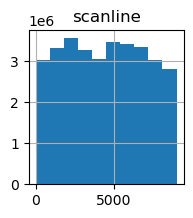

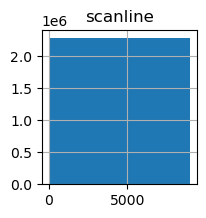

In [9]:
# create pandas dataframes (currently filtering out these properties, can do with more/all later)
columns_rxp = ["timestamp", "beam_origin_x", "beam_origin_y", "beam_origin_z", "beam_direction_x", "beam_direction_y", "beam_direction_z", "scanline", "scanline_idx"]
subset_rxp = {k: rxp.pulses[k] for k in columns_rxp}
df_rxp = pd.DataFrame.from_dict(subset_rxp)

columns_rdbx = ["timestamp", "x", "y", "z", "scanline", "scanline_idx"]
subset_rdbx = {k: rdbx.points[k] for k in columns_rdbx}
df_rdbx = pd.DataFrame.from_dict(subset_rdbx)

min_scanline = df_rdbx[["scanline"]].to_numpy().min()
if min_scanline < -1:
    # scanline in rdbx is in reverse (not sure if this is due to rotation of scanner or just bug)
    # shift (for vis)
    df_rdbx[["scanline"]] = df_rdbx[["scanline"]] + abs(df_rdbx[["scanline"]].min())
    max_scanline = df_rdbx[["scanline"]].to_numpy().max()
    # then invert rxp scanline + shift
    df_rxp[["scanline"]] = df_rxp[["scanline"]]*(-1)
    df_rxp[["scanline"]] = df_rxp[["scanline"]] + max_scanline

    if df_rxp[["scanline"]].to_numpy().max() > df_rdbx[["scanline"]].to_numpy().max():
        # drop last column
        df_rxp.drop(df_rxp.loc[df_rxp['scanline'] > df_rdbx["scanline"].to_numpy().max()].index, inplace=True)

## debug:
df_rdbx
df_rdbx[["scanline"]].hist(figsize=(2,2))
print(df_rdbx[["scanline"]].max())
print(df_rdbx[["scanline"]].min())

df_rxp[["scanline"]].hist(figsize=(2,2))
print(df_rxp[["scanline"]].max())
print(df_rxp[["scanline"]].min())

In [10]:
# merge
merged_df = df_rxp.merge(df_rdbx, how="left", on=["scanline", "scanline_idx"])

# debug:
# merged_df
# unique, counts = np.unique(merged_df[["scanline"]].to_numpy(), return_counts=True)
# print(unique)
# print(counts)

na_mask = merged_df["timestamp_y"].isna()
point_df = merged_df[~na_mask]
empty_pulse_df = merged_df[na_mask]
print(len(point_df.index))
print(len(empty_pulse_df.index))

# debug:
# point_df

32326882
273393


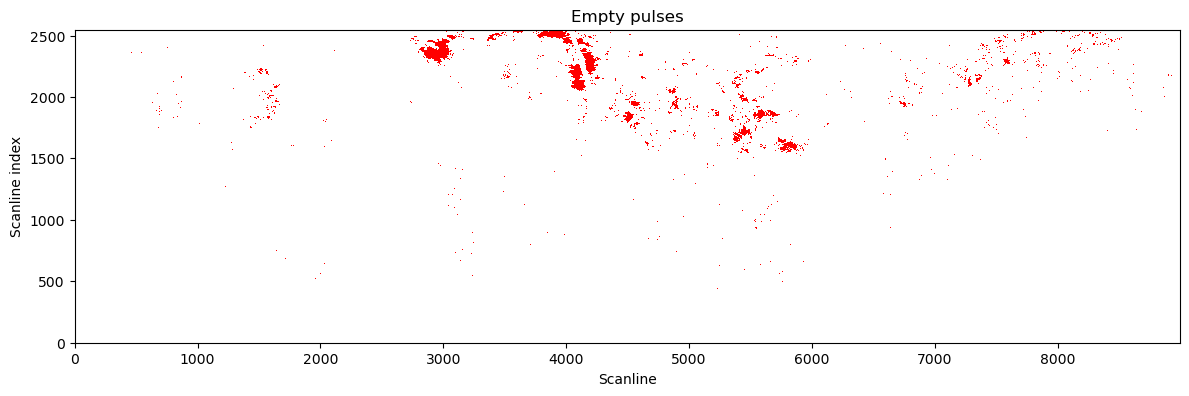

In [12]:
def plot_grid(data : pd.DataFrame, max_scanline, max_scanline_idx, image2=None, out_path=None):
    scanline_np = data[["scanline"]].to_numpy()
    scanline_idx_np = data[["scanline_idx"]].to_numpy()
    # scanline_idx_np = np.where(scanline_idx_np > max_scanline_idx, max_scanline_idx, scanline_idx_np)
    extent = [0, max_scanline+1, 0, max_scanline_idx+1]
    img = np.zeros(shape=(max_scanline_idx+1, max_scanline+1), dtype=bool)
    img[scanline_idx_np, scanline_np] = True
    figsize=(12,5)
    cmap = matplotlib.colors.ListedColormap(['white', 'red'])
    fig, ax = plt.subplots(ncols=1, nrows=1, squeeze=False, 
                           sharex=False, sharey=False, figsize=figsize)
    with plt.style.context('seaborn-v0_8-notebook'):
        ax[0,0].imshow(img, interpolation='nearest', extent=extent, 
                    clim=[0,1], cmap=plt.get_cmap(cmap, 2), vmin=0, vmax=1, alpha=1)
        ax[0,0].set(adjustable='box', aspect='equal')
        ax[0,0].set(xlabel="Scanline", ylabel="Scanline index")
        ax[0,0].set_facecolor('white')
        ax[0,0].set(title="Empty pulses")
        cmap_blue = matplotlib.colors.ListedColormap(['white', 'blue'])
        if image2 is not None:
            ax[0,0].imshow(image2, interpolation='nearest', extent=extent, clim=[0,1], cmap=plt.get_cmap(cmap_blue,2), vmin=0,vmax=1, alpha=0.5)
    fig.tight_layout()
    plt.show()
    if out_path is not None:
        fig.savefig(out_path)


plot_grid(empty_pulse_df, max_scanline, max_scanline_idx)